# Discrete Probability Distribution Functions

This section gives compact examples of common discrete probability distributions.

For each distribution, we include:
- a short explanation of the PMF,
- a small numerical check that probabilities sum to 1 (or close to 1 for truncated support),
- a plot of the probability mass function.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from math import comb, factorial



def pmf_plot(ax, x, p, title, xlabel='k'):
    ax.bar(x, p)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('PMF')

## Bernoulli Distribution

A Bernoulli random variable $X \in \{0,1\}$ models one trial with success probability $p$.

$$
P(X=k)=p^k(1-p)^{1-k},\quad k\in\{0,1\}.
$$

Typical use: detection/non-detection, yes/no outcomes.

Sum of probabilities: 1.0


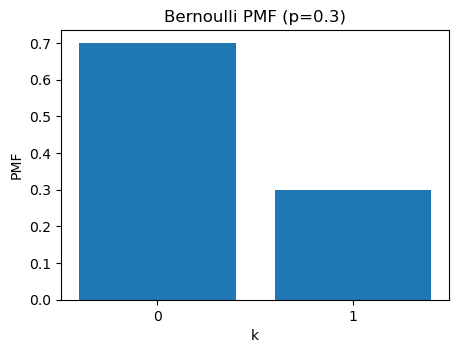

In [2]:
p = 0.3
x = np.array([0, 1])
pmf = np.array([1 - p, p])

print('Sum of probabilities:', pmf.sum())

fig, ax = plt.subplots(figsize=(5, 3.5))
pmf_plot(ax, x, pmf, f'Bernoulli PMF (p={p})')
ax.set_xticks([0, 1])
plt.show()

## Binomial Distribution

If $X$ is the number of successes in $n$ independent Bernoulli trials with success probability $p$, then:

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k},\quad k=0,1,\dots,n.
$$

Typical use: number of detected objects out of a fixed sample.

Sum of probabilities: 1.0


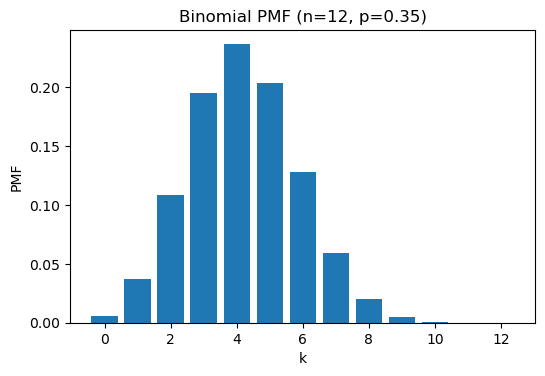

In [3]:
n, p = 12, 0.35
x = np.arange(n + 1)
pmf = np.array([comb(n, k) * (p**k) * ((1 - p)**(n - k)) for k in x])

print('Sum of probabilities:', pmf.sum())

fig, ax = plt.subplots(figsize=(6, 3.8))
pmf_plot(ax, x, pmf, f'Binomial PMF (n={n}, p={p})')
plt.show()

## 3) Poisson Distribution

A Poisson variable models counts in a fixed interval when events happen independently at average rate $\lambda$:

$$
P(X=k)=e^{-\lambda}\frac{\lambda^k}{k!},\quad k=0,1,2,\dots
$$

Typical use: photon counts, galaxy cluster counts.

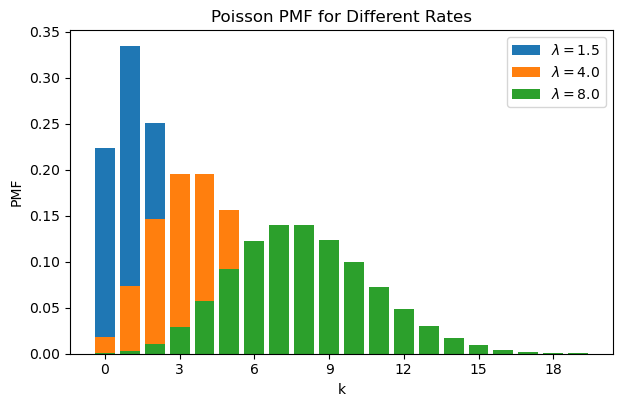

In [4]:
x = np.arange(0, 20)
lambdas = [1.5, 4.0, 8.0]

fig, ax = plt.subplots(figsize=(7, 4.2))
for lam in lambdas:
    pmf = np.array([np.exp(-lam) * (lam**k) / factorial(k) for k in x])
    ax.bar(x, pmf, label=fr'$\lambda={lam}$')

ax.set_title('Poisson PMF for Different Rates')
ax.set_xlabel('k')
ax.set_ylabel('PMF')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend()
plt.show()

## Geometric Distribution

For the number of trials until the first success (support $k=1,2,\dots$):

$$
P(X=k)=(1-p)^{k-1}p.
$$

Typical use: waiting-time style questions in repeated independent trials.

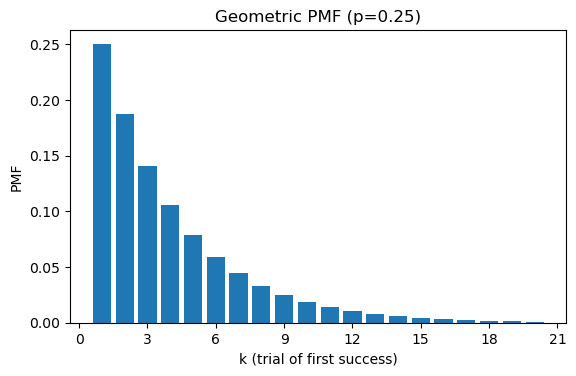

In [5]:
p = 0.25
x = np.arange(1, 21)
pmf = (1 - p) ** (x - 1) * p
fig, ax = plt.subplots(figsize=(6.4, 3.8))
pmf_plot(ax, x, pmf, f'Geometric PMF (p={p})', xlabel='k (trial of first success)')
plt.show()

## Continuous Probability Density Functions (PDFs)

### Normal (Gaussian) Distribution

The normal PDF with mean $\mu$ and standard deviation $\sigma$ is:

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
$$

It is symmetric around $\mu$ and appears in many measurement-noise models.

Normalisation check: 0.9999994263515934


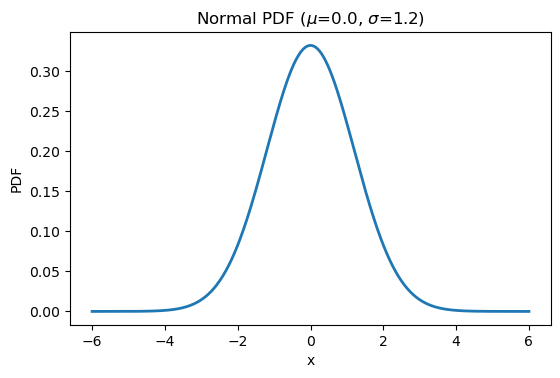

In [11]:
mu, sigma = 0.0, 1.2
x = np.linspace(-6, 6, 600)
pdf = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

norm_check = np.trapezoid(pdf, x)
print('Normalisation check:', norm_check)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(x, pdf, lw=2)
ax.set_title(f'Normal PDF ($\\mu$={mu}, $\\sigma$={sigma})')
ax.set_xlabel('x')
ax.set_ylabel('PDF')
plt.show()

### Exponential Distribution

For waiting times between Poisson events, a common model is:

$$
f(x)=\lambda e^{-\lambda x},\quad x\ge 0.
$$

Larger $\lambda$ concentrates more probability near $x=0$.

Normalisation check: 0.9996793966627613


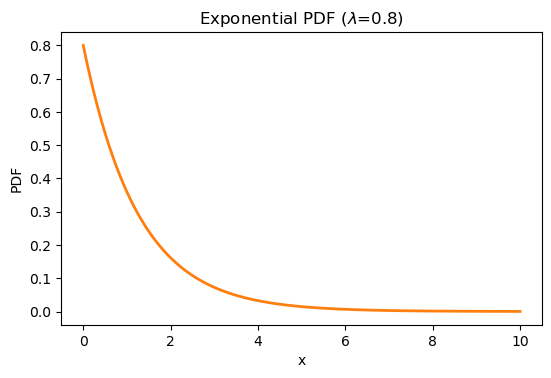

In [13]:
lam = 0.8
x = np.linspace(0, 10, 600)
pdf = lam * np.exp(-lam * x)

norm_check = np.trapezoid(pdf, x)
print('Normalisation check:', norm_check)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(x, pdf, lw=2, color='tab:orange')
ax.set_title(f'Exponential PDF ($\\lambda$={lam})')
ax.set_xlabel('x')
ax.set_ylabel('PDF')
plt.show()

### Uniform Distribution

If all values in $[a,b]$ are equally likely:

$$
f(x)=\frac{1}{b-a},\quad a\le x\le b,
$$

and zero elsewhere.

Normalisation check: 1.0003338898163607


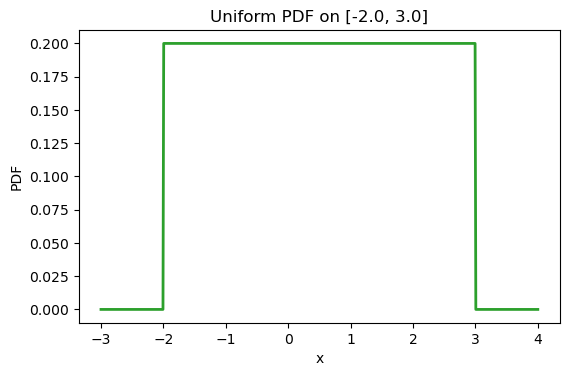

In [14]:
a, b = -2.0, 3.0
x = np.linspace(a - 1, b + 1, 600)
pdf = np.where((x >= a) & (x <= b), 1.0 / (b - a), 0.0)

norm_check = np.trapezoid(pdf, x)
print('Normalisation check:', norm_check)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(x, pdf, lw=2, color='tab:green')
ax.set_title(f'Uniform PDF on [{a}, {b}]')
ax.set_xlabel('x')
ax.set_ylabel('PDF')
plt.show()

### Gamma Distribution

A positive-valued PDF (shape $k$, scale $\theta$):

$$
f(x)=\frac{1}{\Gamma(k)\,\theta^k}x^{k-1}e^{-x/\theta},\quad x\ge 0.
$$

Useful for skewed non-negative quantities.

Normalisation check: 0.9998328184571721


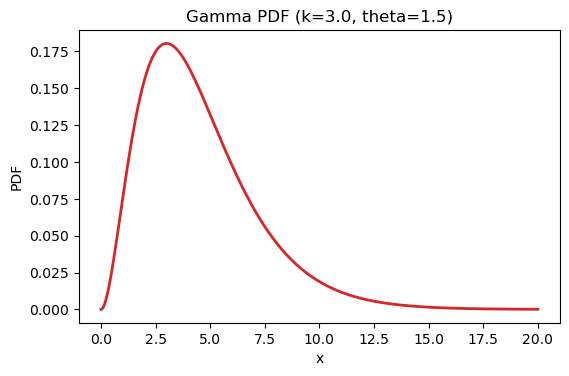

In [15]:
from math import gamma as gamma_func

k, theta = 3.0, 1.5
x = np.linspace(0, 20, 800)
pdf = (x ** (k - 1) * np.exp(-x / theta)) / (gamma_func(k) * theta ** k)

norm_check = np.trapezoid(pdf, x)
print('Normalisation check:', norm_check)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(x, pdf, lw=2, color='tab:red')
ax.set_title(f'Gamma PDF (k={k}, theta={theta})')
ax.set_xlabel('x')
ax.set_ylabel('PDF')
plt.show()

# Bivariate distributions

### Correlated Bivariate Normal

Let $(X,Y)$ follow a correlated Gaussian with parameters $(\mu_x,\mu_y,\sigma_x,\sigma_y,\rho)$. The joint PDF is:

$$
f_{X,Y}(x,y)=\frac{1}{2\pi\sigma_x\sigma_y\sqrt{1-\rho^2}}
\exp\left[-\frac{1}{2(1-\rho^2)}\left(\frac{(x-\mu_x)^2}{\sigma_x^2}-2\rho\frac{(x-\mu_x)(y-\mu_y)}{\sigma_x\sigma_y}+\frac{(y-\mu_y)^2}{\sigma_y^2}\right)\right].
$$

Its marginals are Gaussian: $X\sim\mathcal{N}(\mu_x,\sigma_x^2)$ and $Y\sim\mathcal{N}(\mu_y,\sigma_y^2)$.

Joint normalisation (numeric): 0.9999988580034586


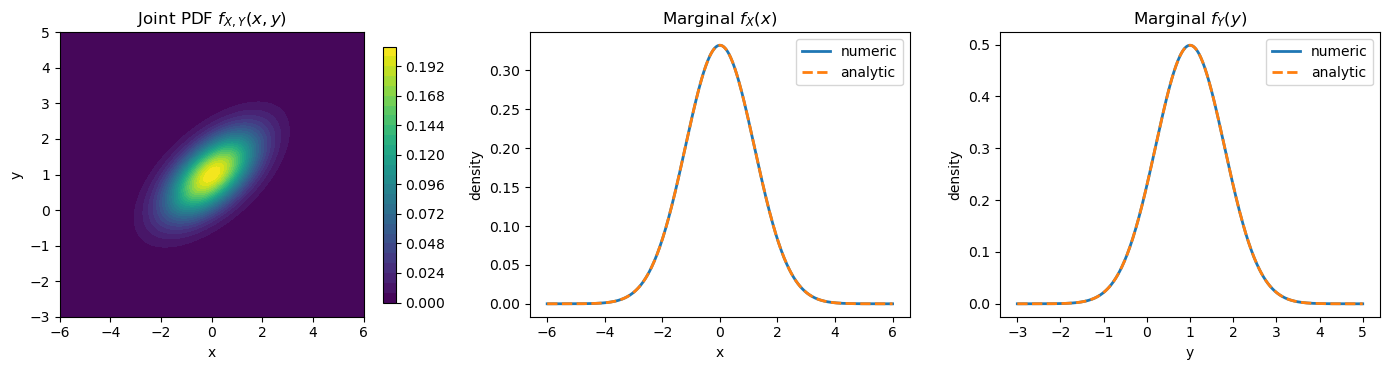

In [26]:
mu_x, mu_y = 0.0, 1.0 # means of X and Y
sigma_x, sigma_y = 1.2, 0.8 # standard deviations of X and Y
rho = 0.6 # correlation coefficient between X and Y
N_grid = 500 # number of points along each axis for numerical integration


# Build a 2D grid where we evaluate the joint PDF.
x = np.linspace(-5*sigma_x + mu_x, 5*sigma_x + mu_x, N_grid)
y = np.linspace(-5*sigma_y + mu_y, 5*sigma_y + mu_y, N_grid)
X, Y = np.meshgrid(x, y)

# Correlated bivariate normal PDF f_{X,Y}(x,y).
z = ((X - mu_x) / sigma_x) ** 2 - 2 * rho * ((X - mu_x) / sigma_x) * ((Y - mu_y) / sigma_y) + ((Y - mu_y) / sigma_y) ** 2
pref = 1.0 / (2 * np.pi * sigma_x * sigma_y * np.sqrt(1 - rho ** 2))
fxy = pref * np.exp(-z / (2 * (1 - rho ** 2)))

# Marginals from numerical integration of the joint PDF.
fx_num = np.trapezoid(fxy, y, axis=0)  # integrate over y
fy_num = np.trapezoid(fxy, x, axis=1)  # integrate over x

# Closed-form marginals for a bivariate normal are 1D normals.
fx_ana = (1.0 / (sigma_x * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu_x) / sigma_x) ** 2)
fy_ana = (1.0 / (sigma_y * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((y - mu_y) / sigma_y) ** 2)

# Diagnostics: total probability and numerical-vs-analytic agreement.
norm_check = np.trapezoid(np.trapezoid(fxy, x, axis=1), y)
err_fx = np.max(np.abs(fx_num - fx_ana))
err_fy = np.max(np.abs(fy_num - fy_ana))
print('Joint normalisation (numeric):', norm_check)

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))

c = axs[0].contourf(X, Y, fxy, levels=25, cmap='viridis')
axs[0].set_title('Joint PDF $f_{X,Y}(x,y)$')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
fig.colorbar(c, ax=axs[0], shrink=0.9)

axs[1].plot(x, fx_num, lw=2, label='numeric')
axs[1].plot(x, fx_ana, '--', lw=2, label='analytic')
axs[1].set_title('Marginal $f_X(x)$')
axs[1].set_xlabel('x')
axs[1].set_ylabel('density')
axs[1].legend()

axs[2].plot(y, fy_num, lw=2, label='numeric')
axs[2].plot(y, fy_ana, '--', lw=2, label='analytic')
axs[2].set_title('Marginal $f_Y(y)$')
axs[2].set_xlabel('y')
axs[2].set_ylabel('density')
axs[2].legend()

plt.tight_layout()
plt.show()

### Example 2: Independent Exponential $\times$ Uniform

Define

$$
f_{X,Y}(x,y)=f_X(x)f_Y(y),
$$

with

$$
f_X(x)=\lambda e^{-\lambda x}\;(x\ge 0),\qquad
f_Y(y)=\frac{1}{b-a}\;(a\le y\le b).
$$

Because of independence, the marginals are exactly $f_X$ and $f_Y$.

Joint normalisation (numeric, truncated x-range): 1.00316847400464


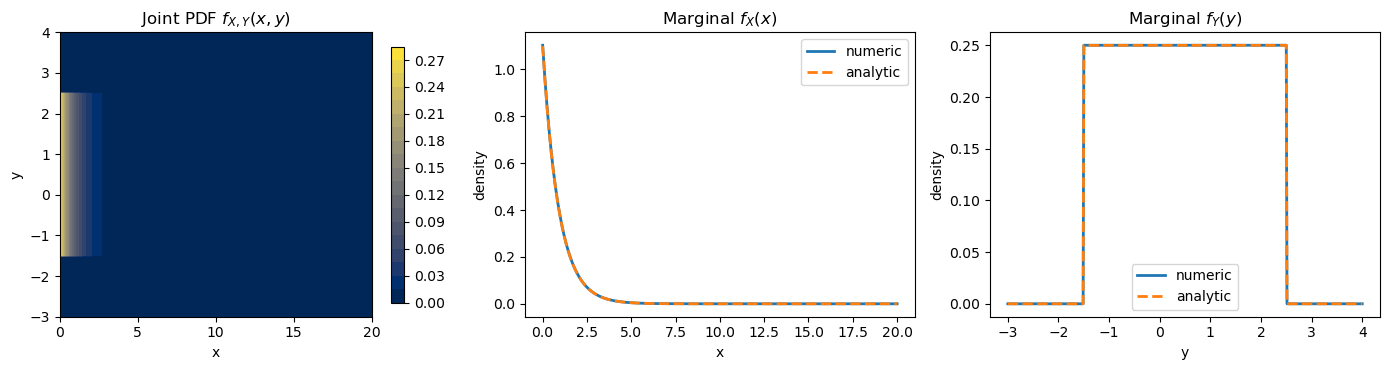

In [27]:
lam = 1.1
a, b = -1.5, 2.5
N_grid = 500

# Finite plotting/integration grid.
x = np.linspace(0, 20, N_grid)
y = np.linspace(-3, 4, N_grid)
X, Y = np.meshgrid(x, y)

# Target analytic marginals.
fx = lam * np.exp(-lam * x)
fy = np.where((y >= a) & (y <= b), 1.0 / (b - a), 0.0)

# Joint PDF from independence: f_{X,Y}(x,y) = f_X(x) f_Y(y).
fxy = (lam * np.exp(-lam * X)) * np.where((Y >= a) & (Y <= b), 1.0 / (b - a), 0.0)

# Numerical marginals recovered from the joint PDF.
fx_num = np.trapezoid(fxy, y, axis=0)  # integrate over y
fy_num = np.trapezoid(fxy, x, axis=1)  # integrate over x

# Diagnostics: note that x is truncated to [0, 8], so total mass is slightly below 1.
norm_check = np.trapezoid(np.trapezoid(fxy, x, axis=1), y)
err_fx = np.max(np.abs(fx_num - fx))
err_fy = np.max(np.abs(fy_num - fy))
print('Joint normalisation (numeric, truncated x-range):', norm_check)

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))

c = axs[0].contourf(X, Y, fxy, levels=25, cmap='cividis')
axs[0].set_title('Joint PDF $f_{X,Y}(x,y)$')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
fig.colorbar(c, ax=axs[0], shrink=0.9)

axs[1].plot(x, fx_num, lw=2, label='numeric')
axs[1].plot(x, fx, '--', lw=2, label='analytic')
axs[1].set_title('Marginal $f_X(x)$')
axs[1].set_xlabel('x')
axs[1].set_ylabel('density')
axs[1].legend()

axs[2].plot(y, fy_num, lw=2, label='numeric')
axs[2].plot(y, fy, '--', lw=2, label='analytic')
axs[2].set_title('Marginal $f_Y(y)$')
axs[2].set_xlabel('y')
axs[2].set_ylabel('density')
axs[2].legend()

plt.tight_layout()
plt.show()